<a href="https://colab.research.google.com/github/itsabhiraj/Abhinav/blob/main/Delhi_AQI_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Welcome to Colab!

In [ ]:
packages = {
    "pandas"              : "Data manipulation",
    "numpy"               : "Numerical computing",
    "matplotlib"          : "Plotting",
    "seaborn"             : "Statistical visualization",
    "scikit-learn"        : "ML utilities",
    "xgboost"             : "Phase 3 baseline",
    "lightgbm"            : "Phase 4 main model",
    "optuna"              : "Hyperparameter tuning",
    "shap"                : "Model explainability",
    "torch"               : "LSTM + TFT",
    "pytorch_forecasting" : "Temporal Fusion Transformer",
    "plotly"              : "Interactive dashboard",
    "geopandas"           : "Spatial prediction maps",
}

print("Environment Check")
print("="*45)
for pkg, purpose in packages.items():
    try:
        __import__(pkg)
        print(f"✅ {pkg:25s} {purpose}")
    except ImportError:
        print(f"❌ {pkg:25s} MISSING — {purpose}")

Environment Check
✅ pandas                    Data manipulation
✅ numpy                     Numerical computing
✅ matplotlib                Plotting
✅ seaborn                   Statistical visualization
❌ scikit-learn              MISSING — ML utilities
✅ xgboost                   Phase 3 baseline
✅ lightgbm                  Phase 4 main model
❌ optuna                    MISSING — Hyperparameter tuning
✅ shap                      Model explainability
✅ torch                     LSTM + TFT
❌ pytorch_forecasting       MISSING — Temporal Fusion Transformer
✅ plotly                    Interactive dashboard
✅ geopandas                 Spatial prediction maps


In [ ]:
pip install scikit-learn optuna pytorch-forecasting

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.3/425.3 kB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.6/848.6 kB 35.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.3/165.3 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 44.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 36.6 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# ── Plot style ────────────────────────────────────────────────────────────────
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["font.size"]      = 12
sns.set_style("whitegrid")

# ── Load master dataset ───────────────────────────────────────────────────────
df = pd.read_csv(
    "/content/drive/MyDrive/Delhi_PM25_AI/data/final/Master_PM25_Dataset.csv",
    parse_dates=["Date"]
)

print(f"Total rows       : {len(df):,}")
print(f"Total columns    : {len(df.columns)}")
print(f"Date range       : {df['Date'].min()} → {df['Date'].max()}")
print(f"Grid cells       : {df['Grid_ID'].nunique()}")

# Split labelled vs unlabelled immediately
labelled   = df.dropna(subset=["PM25"]).copy()
unlabelled = df[df["PM25"].isna()].copy()

print(f"\nLabelled rows    : {len(labelled):,}")
print(f"Unlabelled rows  : {len(unlabelled):,}")
print(f"\nData types:")
print(df.dtypes)
print(f"\nFirst 3 rows:")
print(labelled.head(3).to_string())

Total rows       : 4,175,581
Total columns    : 30
Date range       : 2019-01-01 00:00:00 → 2025-12-31 00:00:00
Grid cells       : 1633

Labelled rows    : 40,440
Unlabelled rows  : 4,135,141

Data types:
Date               datetime64[ns]
Grid_ID                    object
Lat                       float64
Lon                       float64
Year                        int64
Month                       int64
DOY                         int64
Season                     object
AOD                       float64
NO2                       float64
SO2                       float64
CO                        float64
AER_AI                    float64
Temp_C                    float64
Rainfall_mm               float64
Pressure_hPa              float64
Elevation_m               float64
Slope_deg                 float64
Pct_Built_up              float64
Pct_Vegetation            float64
Pct_Cropland              float64
Pct_Water                 float64
Pct_Tree_cover            float64
Road_Density 

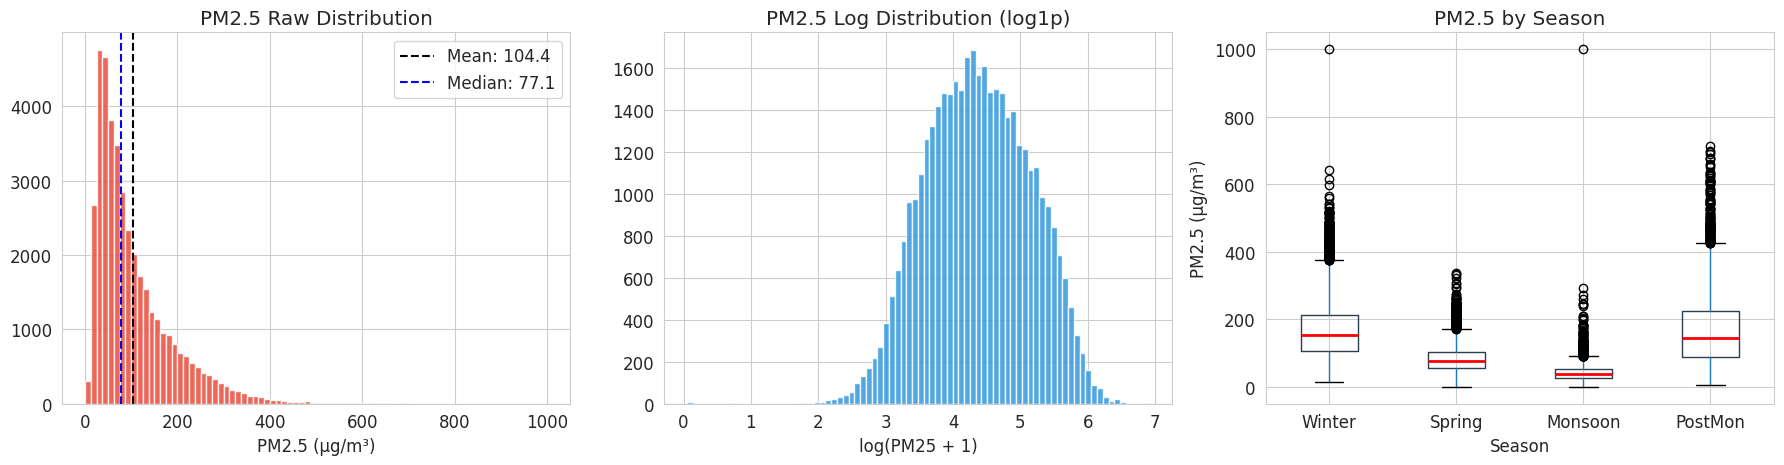

PM2.5 Summary Statistics:
count    40440.0
mean       104.4
std         84.2
min          0.0
25%         43.7
50%         77.1
75%        139.2
max       1000.0
Name: PM25, dtype: float64

Skewness : 1.74  (>1 = right skewed, use log transform)
Kurtosis : 4.27

WHO guideline (24hr): 15 µg/m³
% days above WHO     : 98.6%
% days above 200     : 12.9%
% days above 500     : 0.2%


In [ ]:
import os

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Raw distribution
axes[0].hist(labelled["PM25"], bins=80, color="#E74C3C", edgecolor="white", alpha=0.85)
axes[0].axvline(labelled["PM25"].mean(),   color="black", linestyle="--", label=f'Mean: {labelled["PM25"].mean():.1f}')
axes[0].axvline(labelled["PM25"].median(), color="blue",  linestyle="--", label=f'Median: {labelled["PM25"].median():.1f}')
axes[0].set_title("PM2.5 Raw Distribution")
axes[0].set_xlabel("PM2.5 (µg/m³)")
axes[0].legend()

# Log distribution
axes[1].hist(np.log1p(labelled["PM25"]), bins=80, color="#3498DB", edgecolor="white", alpha=0.85)
axes[1].set_title("PM2.5 Log Distribution (log1p)")
axes[1].set_xlabel("log(PM25 + 1)")

# Boxplot by season
season_order = ["Winter", "Spring", "Monsoon", "PostMon"]
labelled["Season"] = pd.Categorical(labelled["Season"], categories=season_order, ordered=True)
labelled = labelled.sort_values("Season")
labelled.boxplot(column="PM25", by="Season", ax=axes[2],
                 boxprops=dict(color="#2C3E50"),
                 medianprops=dict(color="red", linewidth=2))
axes[2].set_title("PM2.5 by Season")
axes[2].set_xlabel("Season")
axes[2].set_ylabel("PM2.5 (µg/m³)")
plt.suptitle("")

plt.tight_layout()

# Create the directory if it doesn't exist
output_dir = "Delhi_PM25_AI/maps"
os.makedirs(output_dir, exist_ok=True)

plt.savefig(os.path.join(output_dir, "EDA_PM25_Distribution.png"), dpi=150)
plt.show()

# Summary statistics
print("PM2.5 Summary Statistics:")
print(labelled["PM25"].describe().round(1))
print(f"\nSkewness : {labelled['PM25'].skew():.2f}  (>1 = right skewed, use log transform)")
print(f"Kurtosis : {labelled['PM25'].kurt():.2f}")
print(f"\nWHO guideline (24hr): 15 µg/m³")
print(f"% days above WHO     : {(labelled['PM25'] > 15).mean()*100:.1f}%")
print(f"% days above 200     : {(labelled['PM25'] > 200).mean()*100:.1f}%")
print(f"% days above 500     : {(labelled['PM25'] > 500).mean()*100:.1f}%")

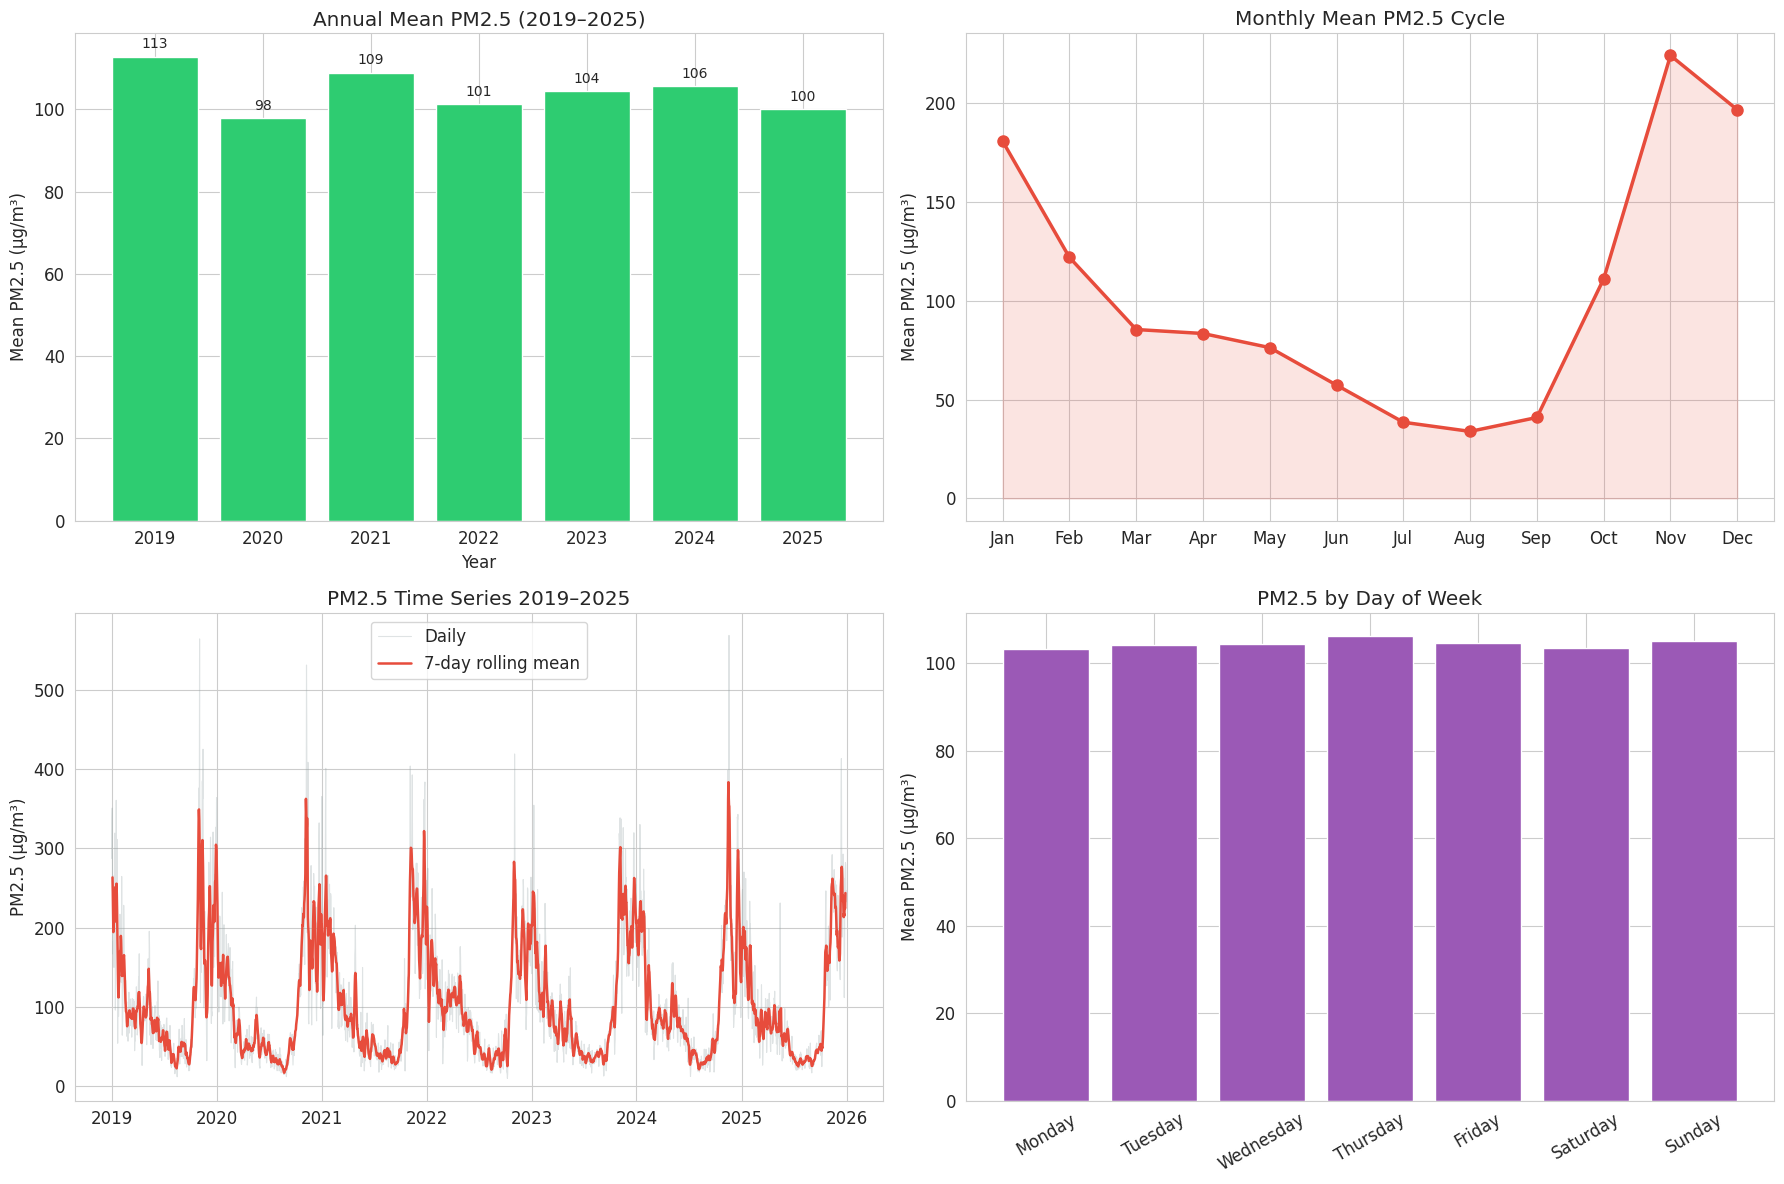

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Annual trend
annual = labelled.groupby("Year")["PM25"].mean()
axes[0,0].bar(annual.index, annual.values, color="#2ECC71", edgecolor="white")
axes[0,0].set_title("Annual Mean PM2.5 (2019–2025)")
axes[0,0].set_xlabel("Year")
axes[0,0].set_ylabel("Mean PM2.5 (µg/m³)")
for i, (yr, val) in enumerate(annual.items()):
    axes[0,0].text(yr, val+2, f"{val:.0f}", ha="center", fontsize=10)

# Monthly pattern
monthly = labelled.groupby("Month")["PM25"].mean()
month_names = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]
axes[0,1].plot(monthly.index, monthly.values, "o-",
               color="#E74C3C", linewidth=2.5, markersize=8)
axes[0,1].set_xticks(range(1,13))
axes[0,1].set_xticklabels(month_names)
axes[0,1].set_title("Monthly Mean PM2.5 Cycle")
axes[0,1].set_ylabel("Mean PM2.5 (µg/m³)")
axes[0,1].fill_between(monthly.index, monthly.values, alpha=0.15, color="#E74C3C")

# Daily time series — rolling 7-day mean
daily_mean = labelled.groupby("Date")["PM25"].mean()
rolling7   = daily_mean.rolling(7, center=True).mean()
axes[1,0].plot(daily_mean.index, daily_mean.values,
               alpha=0.3, color="#95A5A6", linewidth=0.8, label="Daily")
axes[1,0].plot(rolling7.index, rolling7.values,
               color="#E74C3C", linewidth=1.8, label="7-day rolling mean")
axes[1,0].set_title("PM2.5 Time Series 2019–2025")
axes[1,0].set_ylabel("PM2.5 (µg/m³)")
axes[1,0].legend()

# Day of week pattern
labelled["DayOfWeek"] = labelled["Date"].dt.day_name()
dow_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
dow_mean  = labelled.groupby("DayOfWeek")["PM25"].mean().reindex(dow_order)
axes[1,1].bar(dow_mean.index, dow_mean.values, color="#9B59B6", edgecolor="white")
axes[1,1].set_title("PM2.5 by Day of Week")
axes[1,1].set_ylabel("Mean PM2.5 (µg/m³)")
axes[1,1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("Delhi_PM25_AI/maps/EDA_Temporal_Patterns.png", dpi=150)
plt.show()

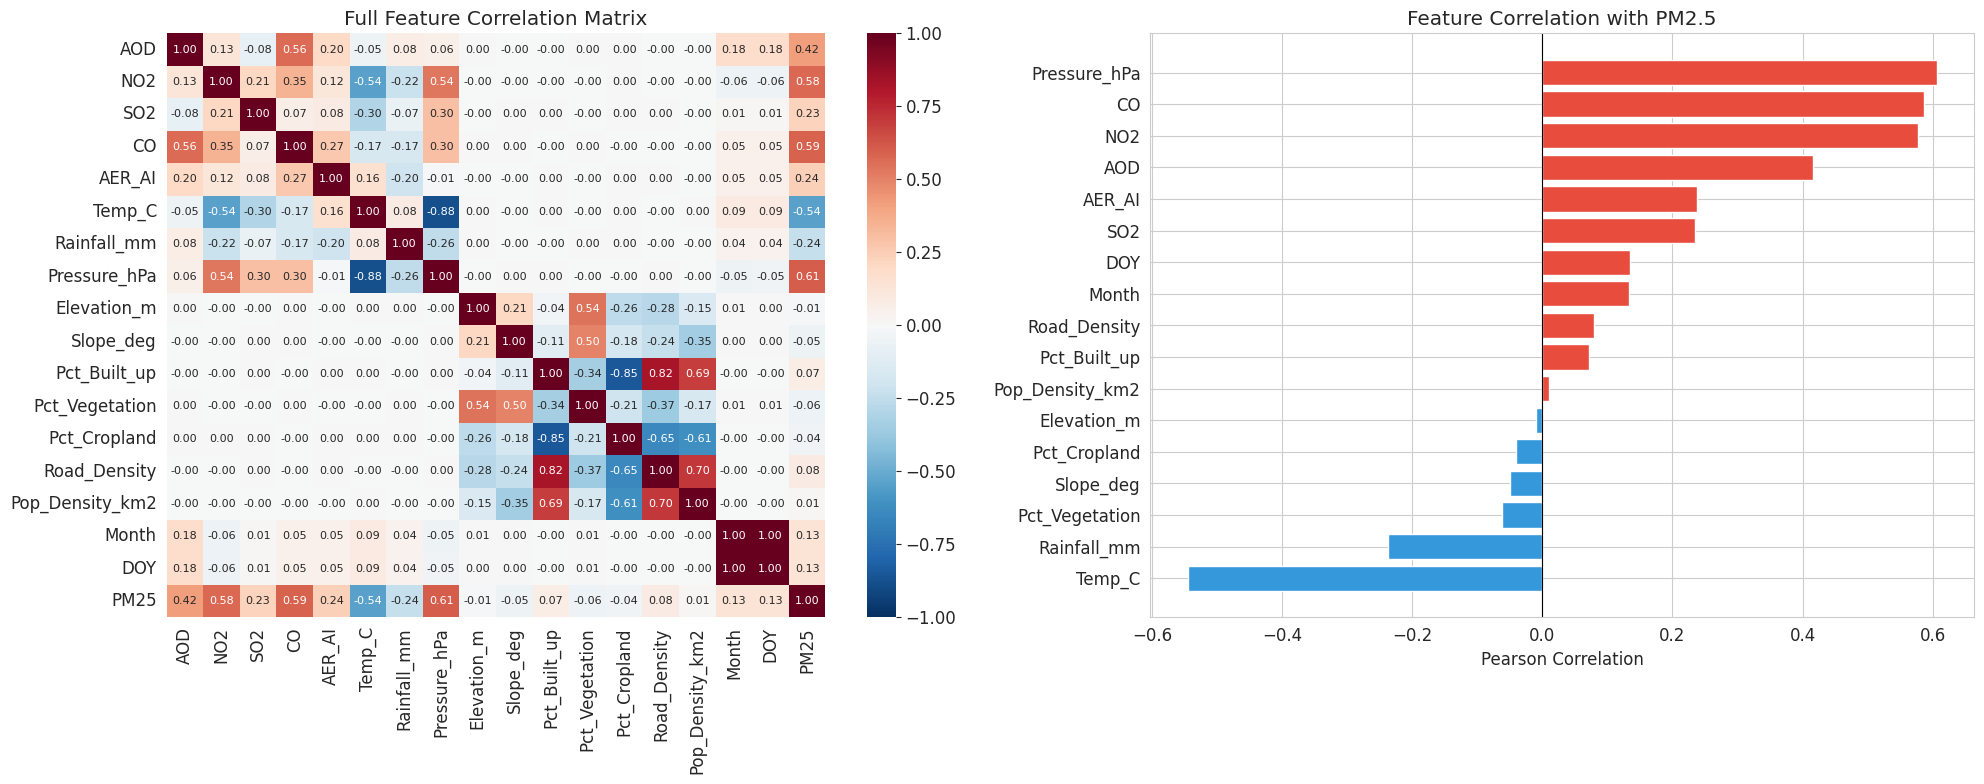

Top features correlated with PM2.5:
Pressure_hPa       0.606
CO                 0.587
NO2                0.578
AOD                0.416
AER_AI             0.237
SO2                0.234
DOY                0.134
Month              0.133
Road_Density       0.080
Pct_Built_up       0.072
Pop_Density_km2    0.010
Elevation_m       -0.010
Pct_Cropland      -0.040
Slope_deg         -0.050
Pct_Vegetation    -0.062
Rainfall_mm       -0.238
Temp_C            -0.545


In [ ]:
# Select only labelled rows and numeric features
numeric_features = [
    "AOD", "NO2", "SO2", "CO", "AER_AI",
    "Temp_C", "RH", "Wind_Speed_ms", "Wind_Dir_deg",
    "Rainfall_mm", "Pressure_hPa",
    "Elevation_m", "Slope_deg",
    "Pct_Built_up", "Pct_Vegetation", "Pct_Cropland",
    "Road_Density", "Pop_Density_km2",
    "Month", "DOY", "PM25"
]

numeric_features = [c for c in numeric_features if c in labelled.columns]
corr_df = labelled[numeric_features].corr()

# Full correlation heatmap
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(
    corr_df, annot=True, fmt=".2f", cmap="RdBu_r",
    center=0, vmin=-1, vmax=1,
    ax=axes[0], annot_kws={"size": 8}
)
axes[0].set_title("Full Feature Correlation Matrix")

# PM2.5 correlation bar chart — most important
pm25_corr = corr_df["PM25"].drop("PM25").sort_values()
colors    = ["#E74C3C" if v > 0 else "#3498DB" for v in pm25_corr.values]
axes[1].barh(pm25_corr.index, pm25_corr.values, color=colors, edgecolor="white")
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("Feature Correlation with PM2.5")
axes[1].set_xlabel("Pearson Correlation")

plt.tight_layout()
plt.savefig("Delhi_PM25_AI/maps/EDA_Correlations.png", dpi=150)
plt.show()

# Print top correlations
print("Top features correlated with PM2.5:")
print(corr_df["PM25"].drop("PM25").sort_values(ascending=False).round(3).to_string())

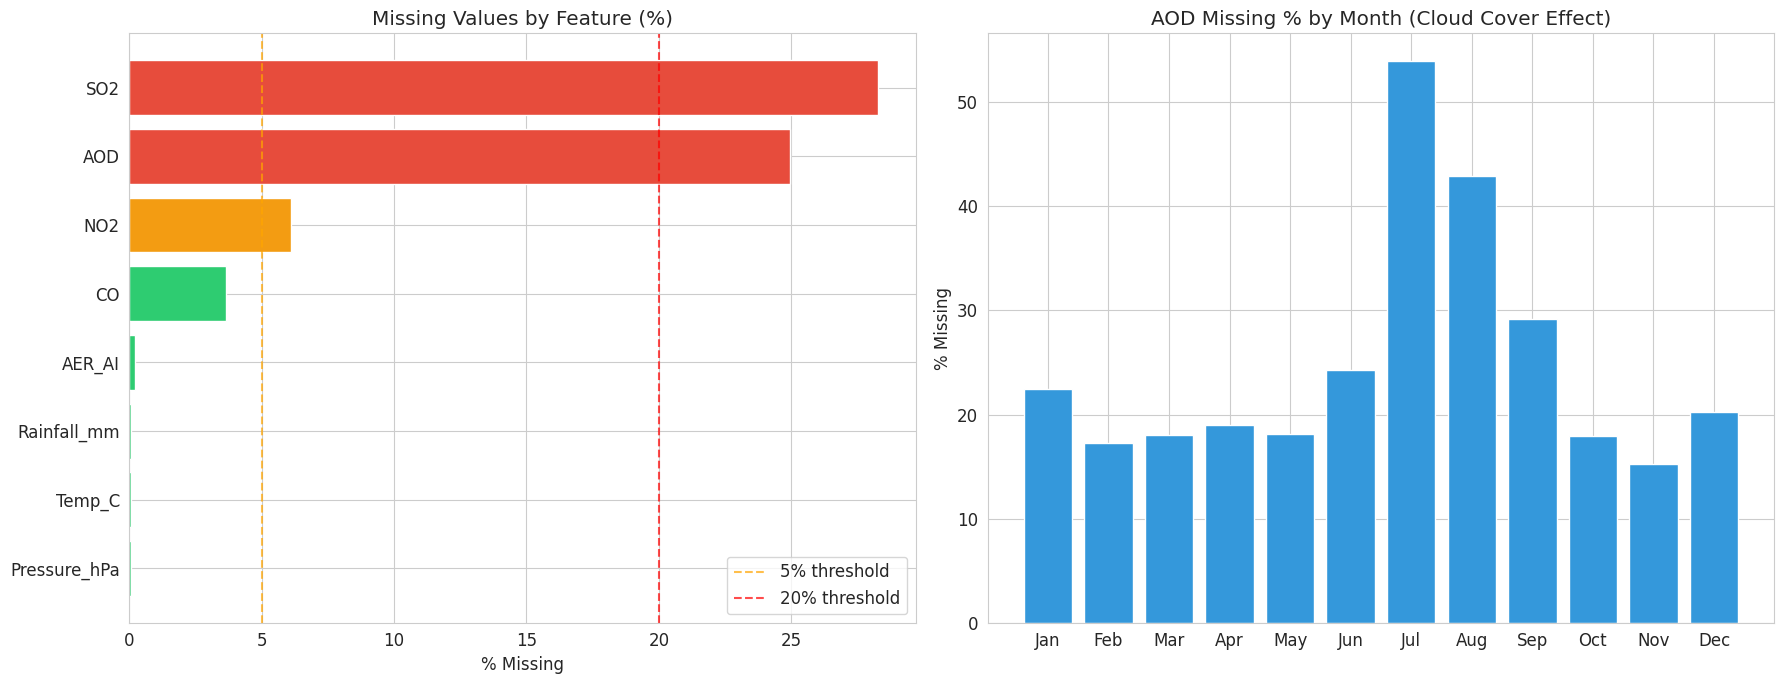

Missing value summary:
Pressure_hPa     0.0
Temp_C           0.0
Rainfall_mm      0.0
AER_AI           0.2
CO               3.7
NO2              6.1
AOD             25.0
SO2             28.3


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Missing value heatmap across features
missing = labelled[numeric_features].isna().sum()
missing_pct = (missing / len(labelled) * 100).sort_values(ascending=True)
missing_pct = missing_pct[missing_pct > 0]

colors = ["#E74C3C" if v > 20 else "#F39C12" if v > 5 else "#2ECC71"
          for v in missing_pct.values]

axes[0].barh(missing_pct.index, missing_pct.values, color=colors, edgecolor="white")
axes[0].axvline(5,  color="orange", linestyle="--", alpha=0.7, label="5% threshold")
axes[0].axvline(20, color="red",    linestyle="--", alpha=0.7, label="20% threshold")
axes[0].set_title("Missing Values by Feature (%)")
axes[0].set_xlabel("% Missing")
axes[0].legend()

# Missing AOD by month — cloud cover pattern
labelled["AOD_missing"] = labelled["AOD"].isna().astype(int)
aod_missing_monthly = labelled.groupby("Month")["AOD_missing"].mean() * 100
axes[1].bar(aod_missing_monthly.index, aod_missing_monthly.values,
            color="#3498DB", edgecolor="white")
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun",
                          "Jul","Aug","Sep","Oct","Nov","Dec"])
axes[1].set_title("AOD Missing % by Month (Cloud Cover Effect)")
axes[1].set_ylabel("% Missing")

plt.tight_layout()
plt.savefig("Delhi_PM25_AI/maps/EDA_Missing_Values.png", dpi=150)
plt.show()

print("Missing value summary:")
print(missing_pct.round(1).to_string())

Using features: ['PM25', 'AOD', 'Temp_C', 'NO2', 'Rainfall_mm', 'Pressure_hPa']


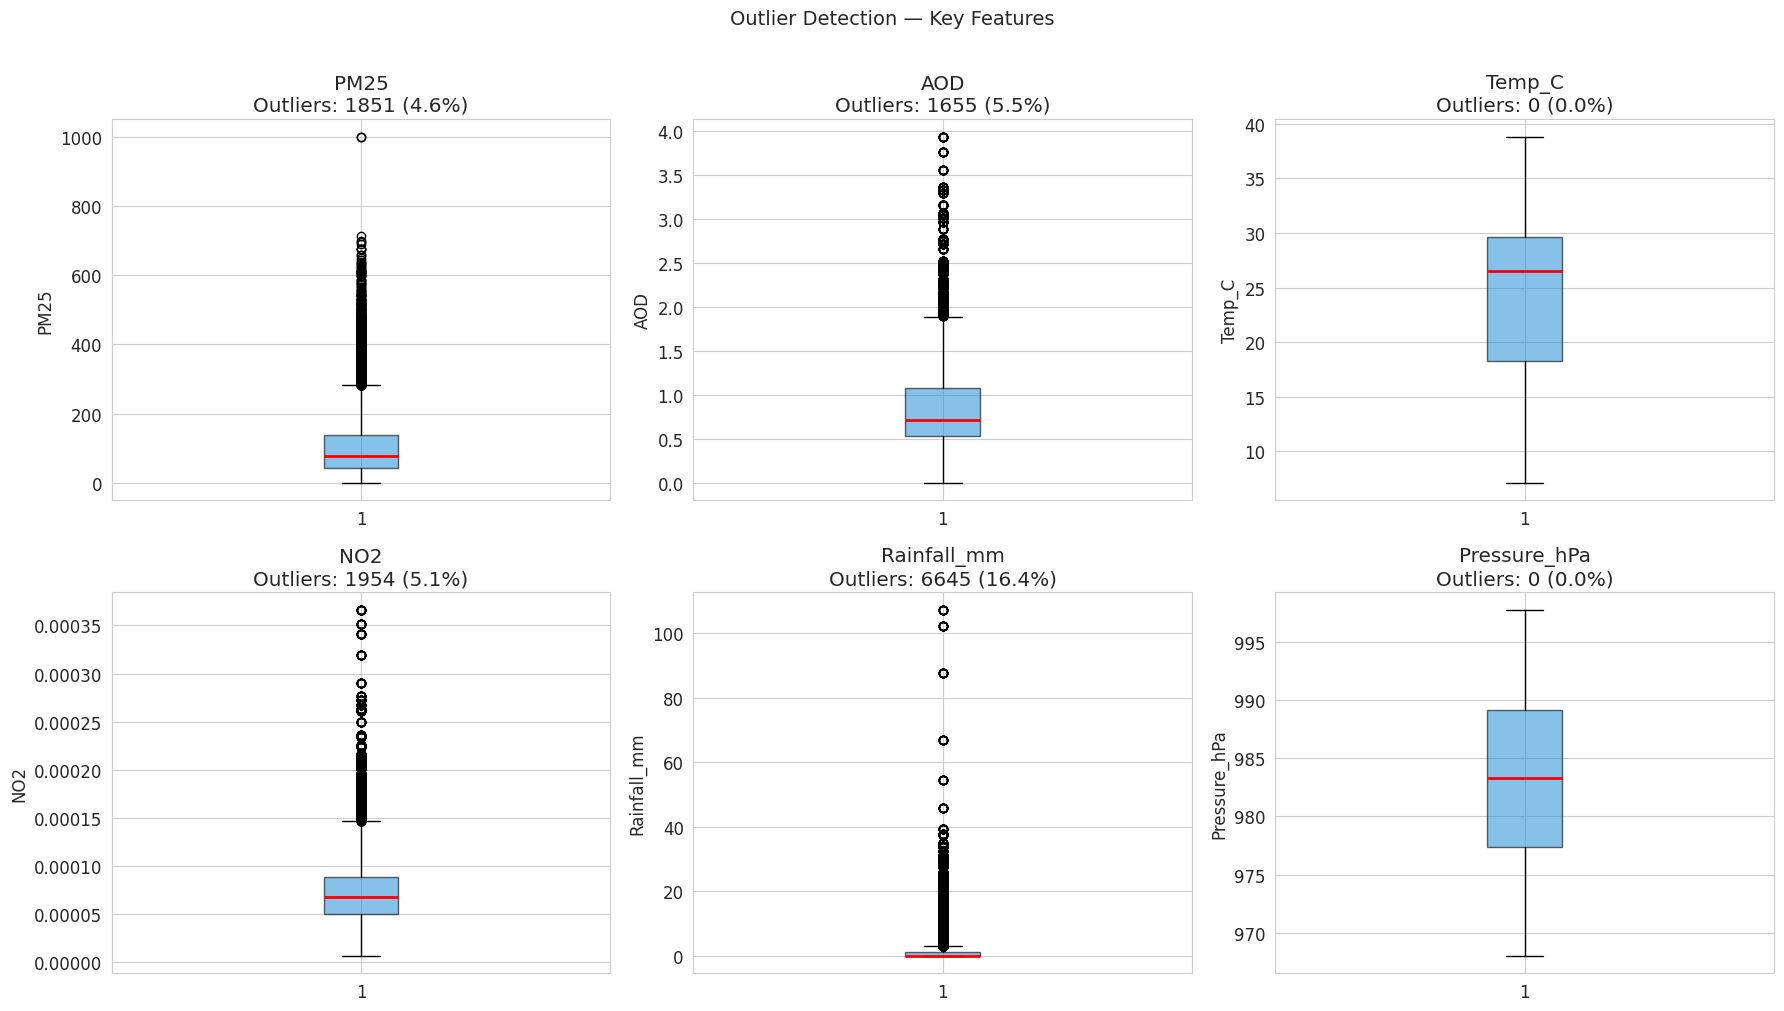

Extreme PM2.5 events (> 500 µg/m³):
              Date     Grid_ID     PM25  Month   Season     Temp_C
3277077 2024-06-29  DELHI_1878  1000.00      6  Monsoon  29.231381
2945578 2023-12-09  DELHI_1878  1000.00     12   Winter  16.490414
501213  2019-11-03  DELHI_2281   712.11     11  PostMon  23.963748
1108189 2020-11-09  DELHI_1520   698.96     11  PostMon  20.650947
501064  2019-11-03  DELHI_2021   696.78     11  PostMon  23.963748
501208  2019-11-03  DELHI_2276   689.10     11  PostMon  23.963748
3508699 2024-11-18  DELHI_1520   677.00     11  PostMon  19.432280
3508484 2024-11-18  DELHI_1245   676.79     11  PostMon  19.432280
3508788 2024-11-18  DELHI_1633   675.09     11  PostMon  19.432280
1117767 2020-11-15  DELHI_1240   659.29     11  PostMon  21.336871
1108391 2020-11-09  DELHI_1783   658.26     11  PostMon  20.650947
1108540 2020-11-09  DELHI_2021   650.05     11  PostMon  20.650947
3601982 2025-01-14  DELHI_1783   643.00      1   Winter  12.939606
3508061 2024-11-18  DELHI_

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Automatically pick columns that actually exist
candidates = ["PM25", "AOD", "Temp_C", "RH", "Wind_Speed_ms",
              "Wind_speed_ms", "wind_speed_ms", "WindSpeed",
              "NO2", "Rainfall_mm", "Pressure_hPa"]

# Keep only columns that exist in the dataframe
key_features = []
seen = set()
for col in candidates:
    match = [c for c in labelled.columns if c.lower() == col.lower()]
    if match and match[0] not in seen:
        key_features.append(match[0])
        seen.add(match[0])
    if len(key_features) == 6:
        break

print(f"Using features: {key_features}")

for ax, feat in zip(axes.flatten(), key_features):
    data = labelled[feat].dropna()
    Q1   = data.quantile(0.25)
    Q3   = data.quantile(0.75)
    IQR  = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((data < lower) | (data > upper)).sum()

    ax.boxplot(data, vert=True, patch_artist=True,
               boxprops=dict(facecolor="#3498DB", alpha=0.6),
               medianprops=dict(color="red", linewidth=2))
    ax.set_title(f"{feat}\nOutliers: {outliers} ({outliers/len(data)*100:.1f}%)")
    ax.set_ylabel(feat)

plt.suptitle("Outlier Detection — Key Features", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("Delhi_PM25_AI/maps/EDA_Outliers.png", dpi=150)
plt.show()

# Extreme PM2.5 events
available_cols = ["Date","Grid_ID","PM25","Month","Season","Temp_C"]
available_cols = [c for c in available_cols if c in labelled.columns]

print("Extreme PM2.5 events (> 500 µg/m³):")
extreme = labelled[labelled["PM25"] > 500][available_cols].sort_values(
    "PM25", ascending=False
)
print(extreme.head(20).to_string())

In [ ]:
labelled = df.dropna(subset=["PM25"]).copy()
labelled = labelled.sort_values(["Grid_ID", "Date"]).reset_index(drop=True)

print(f"Labelled rows : {len(labelled):,}")
print(f"Grid cells    : {labelled['Grid_ID'].nunique()}")
print(f"Date range    : {labelled['Date'].min()} → {labelled['Date'].max()}")

In [ ]:
# ── AOD: temporal interpolation per grid cell, then seasonal median fallback ──
labelled["AOD"] = (
    labelled.groupby("Grid_ID")["AOD"]
    .transform(lambda x: x.interpolate(method="linear", limit=5))
)
seasonal_aod = labelled.groupby(["Grid_ID","Season"])["AOD"].transform("median")
labelled["AOD"] = labelled["AOD"].fillna(seasonal_aod)
labelled["AOD"] = labelled["AOD"].fillna(labelled["AOD"].median())

# ── NO2, CO: linear interpolation (low missing %) ──────────────────────────────
for col in ["NO2", "CO"]:
    labelled[col] = (
        labelled.groupby("Grid_ID")[col]
        .transform(lambda x: x.interpolate(method="linear", limit=5))
    )
    labelled[col] = labelled[col].fillna(labelled[col].median())

# ── SO2: seasonal median imputation (28% missing — needs robust strategy) ─────
labelled["SO2_was_missing"] = labelled["SO2"].isna().astype(int)  # flag for model
seasonal_so2 = labelled.groupby(["Season","Year"])["SO2"].transform("median")
labelled["SO2"] = labelled["SO2"].fillna(seasonal_so2)
labelled["SO2"] = labelled["SO2"].fillna(labelled["SO2"].median())

# ── PM25_std: single station = no spread ───────────────────────────────────────
labelled["PM25_std"] = labelled["PM25_std"].fillna(0)

# ── Verify no missing values remain in key features ───────────────────────────
key_features = ["AOD","NO2","SO2","CO","AER_AI","Temp_C",
                "Rainfall_mm","Pressure_hPa","Elevation_m","Slope_deg",
                "Pct_Built_up","Pct_Vegetation","Road_Density","Pop_Density_km2"]

print("Missing values after imputation:")
print(labelled[key_features].isna().sum())

Missing values after imputation:
AOD                 0
NO2                 0
SO2                 0
CO                  0
AER_AI             79
Temp_C             16
Rainfall_mm        16
Pressure_hPa       16
Elevation_m         0
Slope_deg           0
Pct_Built_up        0
Pct_Vegetation      0
Road_Density        0
Pop_Density_km2     0
dtype: int64


In [ ]:
# PM2.5 is strongly autocorrelated — yesterday's pollution predicts today's
labelled = labelled.sort_values(["Grid_ID","Date"])

for lag in [1, 2, 3, 7]:
    labelled[f"PM25_lag{lag}"] = labelled.groupby("Grid_ID")["PM25"].shift(lag)

labelled["PM25_roll3"]  = (
    labelled.groupby("Grid_ID")["PM25"]
    .transform(lambda x: x.shift(1).rolling(3).mean())
)
labelled["PM25_roll7"]  = (
    labelled.groupby("Grid_ID")["PM25"]
    .transform(lambda x: x.shift(1).rolling(7).mean())
)
labelled["PM25_roll7_std"] = (
    labelled.groupby("Grid_ID")["PM25"]
    .transform(lambda x: x.shift(1).rolling(7).std())
)

# AOD rolling — satellite trend
labelled["AOD_roll3"] = (
    labelled.groupby("Grid_ID")["AOD"]
    .transform(lambda x: x.shift(1).rolling(3).mean())
)

print(f"Rows before dropping lag NaNs : {len(labelled):,}")
labelled = labelled.dropna(subset=["PM25_lag7"])  # drops first 7 days per cell
print(f"Rows after dropping lag NaNs  : {len(labelled):,}")

Rows before dropping lag NaNs : 40,440
Rows after dropping lag NaNs  : 40,328


In [ ]:
# AOD × humidity proxy — aerosol hygroscopic growth (RH not available, use season)
labelled["AOD_Temp"] = labelled["AOD"] * labelled["Temp_C"]

# Pollutant ratios — source signature
labelled["NO2_CO_ratio"] = labelled["NO2"] / (labelled["CO"] + 1e-6)

# Urban intensity score
labelled["Urban_Pop_Index"] = labelled["Pct_Built_up"] * labelled["Pop_Density_km2"] / 1000

# Cyclical encoding for Day of Year — captures seasonality smoothly
labelled["DOY_sin"] = np.sin(2 * np.pi * labelled["DOY"] / 365)
labelled["DOY_cos"] = np.cos(2 * np.pi * labelled["DOY"] / 365)

# Log transform target — fixes right skew
labelled["log_PM25"] = np.log1p(labelled["PM25"])

print("New features created:")
print(["AOD_Temp","NO2_CO_ratio","Urban_Pop_Index","DOY_sin","DOY_cos","log_PM25"])
print(labelled[["AOD_Temp","NO2_CO_ratio","Urban_Pop_Index","log_PM25"]].describe().round(2))

New features created:
['AOD_Temp', 'NO2_CO_ratio', 'Urban_Pop_Index', 'DOY_sin', 'DOY_cos', 'log_PM25']
       AOD_Temp  NO2_CO_ratio  Urban_Pop_Index  log_PM25
count  40312.00      40328.00         40328.00  40328.00
mean      21.13          0.00          1257.66      4.37
std       12.53          0.00          1185.05      0.77
min        0.05          0.00            10.09      0.05
25%       12.77          0.00           416.49      3.80
50%       17.89          0.00           816.83      4.36
75%       26.29          0.00          2592.86      4.94
max       99.43          0.01          3455.81      6.91


In [ ]:
# One-hot encode Season
labelled = pd.get_dummies(labelled, columns=["Season"], prefix="Season")

season_cols = [c for c in labelled.columns if c.startswith("Season_")]
print(f"Season columns created: {season_cols}")

Season columns created: ['Season_Winter', 'Season_Spring', 'Season_Monsoon', 'Season_PostMon']


In [ ]:
# Cap extreme PM2.5 at 99.5th percentile — preserves signal, removes sensor errors
upper_cap = labelled["PM25"].quantile(0.995)
print(f"99.5th percentile PM2.5 : {upper_cap:.1f} µg/m³")
print(f"Rows above cap          : {(labelled['PM25'] > upper_cap).sum()}")

labelled["PM25_capped"]     = labelled["PM25"].clip(upper=upper_cap)
labelled["log_PM25_capped"] = np.log1p(labelled["PM25_capped"])

# Cap AOD outliers (sensor noise above 5.0 already removed in Step 5, but check)
print(f"\nAOD range: {labelled['AOD'].min():.2f} to {labelled['AOD'].max():.2f}")

99.5th percentile PM2.5 : 433.4 µg/m³
Rows above cap          : 202

AOD range: 0.00 to 3.94


In [ ]:
train = labelled[labelled["Year"] <= 2023].copy()
val   = labelled[labelled["Year"] == 2024].copy()
test  = labelled[labelled["Year"] == 2025].copy()

print(f"Train : {len(train):,} rows  ({train['Date'].min()} → {train['Date'].max()})")
print(f"Val   : {len(val):,} rows  ({val['Date'].min()} → {val['Date'].max()})")
print(f"Test  : {len(test):,} rows  ({test['Date'].min()} → {test['Date'].max()})")

# ── Define final feature list ─────────────────────────────────────────────────
feature_cols = [
    "AOD","NO2","SO2","CO","AER_AI","SO2_was_missing",
    "Temp_C","Rainfall_mm","Pressure_hPa",
    "Elevation_m","Slope_deg",
    "Pct_Built_up","Pct_Vegetation","Pct_Cropland","Pct_Water","Pct_Tree_cover",
    "Road_Density","Pop_Density_km2","Urban_Pop_Index",
    "AOD_Temp","NO2_CO_ratio",
    "DOY_sin","DOY_cos",
    "PM25_lag1","PM25_lag2","PM25_lag3","PM25_lag7",
    "PM25_roll3","PM25_roll7","PM25_roll7_std","AOD_roll3",
] + season_cols

feature_cols = [c for c in feature_cols if c in labelled.columns]
target_col   = "log_PM25_capped"

print(f"\nTotal features: {len(feature_cols)}")

X_train, y_train = train[feature_cols], train[target_col]
X_val,   y_val   = val[feature_cols],   val[target_col]
X_test,  y_test  = test[feature_cols],  test[target_col]

# ── Save processed splits ─────────────────────────────────────────────────────
import os
os.makedirs("Delhi_PM25_AI/data/processed/ml_ready", exist_ok=True)

train.to_csv("Delhi_PM25_AI/data/processed/ml_ready/train.csv", index=False)
val.to_csv("Delhi_PM25_AI/data/processed/ml_ready/val.csv", index=False)
test.to_csv("Delhi_PM25_AI/data/processed/ml_ready/test.csv", index=False)

import json
with open("Delhi_PM25_AI/data/processed/ml_ready/feature_cols.json", "w") as f:
    json.dump(feature_cols, f)

print(f"\n✅ Preprocessing complete")
print(f"Saved train/val/test splits to data/processed/ml_ready/")

Train : 28,770 rows  (2019-01-08 00:00:00 → 2023-12-31 00:00:00)
Val   : 5,744 rows  (2024-01-01 00:00:00 → 2024-12-31 00:00:00)
Test  : 5,814 rows  (2025-01-01 00:00:00 → 2025-12-31 00:00:00)

Total features: 35

✅ Preprocessing complete
Saved train/val/test splits to data/processed/ml_ready/


## XGBoost baseline

In [ ]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import json

# Reload splits if starting fresh
import pandas as pd
train = pd.read_csv("Delhi_PM25_AI/data/processed/ml_ready/train.csv", parse_dates=["Date"])
val   = pd.read_csv("Delhi_PM25_AI/data/processed/ml_ready/val.csv",   parse_dates=["Date"])
test  = pd.read_csv("Delhi_PM25_AI/data/processed/ml_ready/test.csv", parse_dates=["Date"])

with open("Delhi_PM25_AI/data/processed/ml_ready/feature_cols.json") as f:
    feature_cols = json.load(f)

target_col = "log_PM25_capped"

X_train, y_train = train[feature_cols], train[target_col]
X_val,   y_val   = val[feature_cols],   val[target_col]
X_test,  y_test  = test[feature_cols],  test[target_col]

# ── Train baseline XGBoost ────────────────────────────────────────────────────
model = xgb.XGBRegressor(
    n_estimators       = 500,
    max_depth          = 6,
    learning_rate      = 0.05,
    subsample          = 0.8,
    colsample_bytree   = 0.8,
    min_child_weight   = 3,
    random_state       = 42,
    early_stopping_rounds = 30,
    eval_metric        = "rmse"
)

model.fit(
    X_train, y_train,
    eval_set = [(X_train, y_train), (X_val, y_val)],
    verbose  = 50
)

print(f"\nBest iteration: {model.best_iteration}")

[0]	validation_0-rmse:0.73384	validation_1-rmse:0.73994
[50]	validation_0-rmse:0.25151	validation_1-rmse:0.29333
[100]	validation_0-rmse:0.21491	validation_1-rmse:0.28746
[112]	validation_0-rmse:0.21076	validation_1-rmse:0.28796

Best iteration: 82


In [ ]:
def evaluate(model, X, y, set_name, log_transform=True):
    preds_log = model.predict(X)

    if log_transform:
        preds_actual = np.expm1(preds_log)
        y_actual     = np.expm1(y)
    else:
        preds_actual = preds_log
        y_actual     = y

    mae  = mean_absolute_error(y_actual, preds_actual)
    rmse = np.sqrt(mean_squared_error(y_actual, preds_actual))
    r2   = r2_score(y_actual, preds_actual)
    mape = np.mean(np.abs((y_actual - preds_actual) / y_actual)) * 100

    print(f"\n{set_name} Performance:")
    print(f"  MAE  : {mae:.2f} µg/m³")
    print(f"  RMSE : {rmse:.2f} µg/m³")
    print(f"  R²   : {r2:.4f}")
    print(f"  MAPE : {mape:.1f}%")

    return {"MAE": mae, "RMSE": rmse, "R2": r2, "MAPE": mape}

train_metrics = evaluate(model, X_train, y_train, "Train")
val_metrics   = evaluate(model, X_val,   y_val,   "Validation")
test_metrics  = evaluate(model, X_test,  y_test,  "Test")


Train Performance:
  MAE  : 16.33 µg/m³
  RMSE : 25.15 µg/m³
  R²   : 0.9055
  MAPE : 19.7%

Validation Performance:
  MAE  : 21.15 µg/m³
  RMSE : 32.83 µg/m³
  R²   : 0.8442
  MAPE : 37.7%

Test Performance:
  MAE  : 20.75 µg/m³
  RMSE : 33.43 µg/m³
  R²   : 0.8273
  MAPE : 53.9%


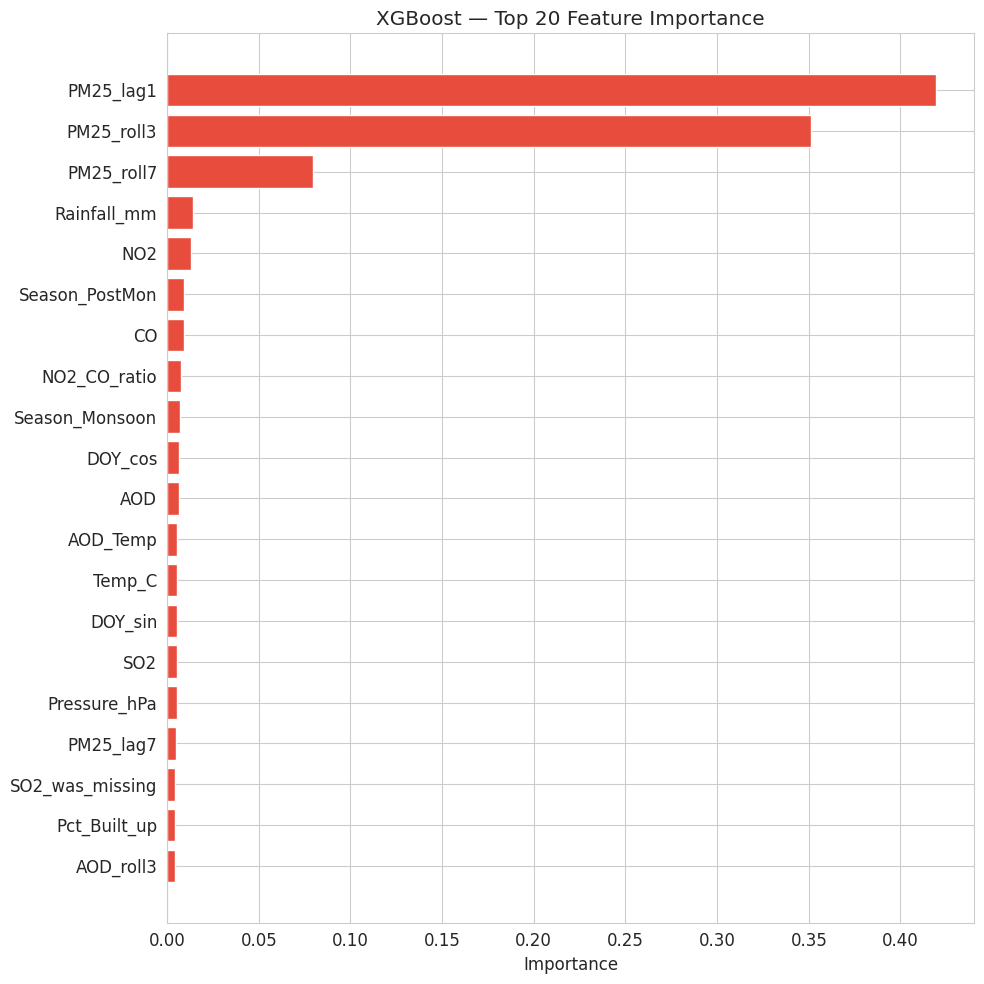

           feature  importance
23       PM25_lag1    0.419136
27      PM25_roll3    0.351243
28      PM25_roll7    0.079848
7      Rainfall_mm    0.014251
1              NO2    0.012813
34  Season_PostMon    0.009467
3               CO    0.009108
20    NO2_CO_ratio    0.007587
33  Season_Monsoon    0.007011
22         DOY_cos    0.006745
0              AOD    0.006652
19        AOD_Temp    0.005553
6           Temp_C    0.005545
21         DOY_sin    0.005359
2              SO2    0.005313


In [ ]:
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "feature"   : feature_cols,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(10, 10))
plt.barh(importance["feature"][:20][::-1], importance["importance"][:20][::-1],
         color="#E74C3C", edgecolor="white")
plt.title("XGBoost — Top 20 Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("Delhi_PM25_AI/maps/XGB_Feature_Importance.png", dpi=150)
plt.show()

print(importance.head(15).to_string())

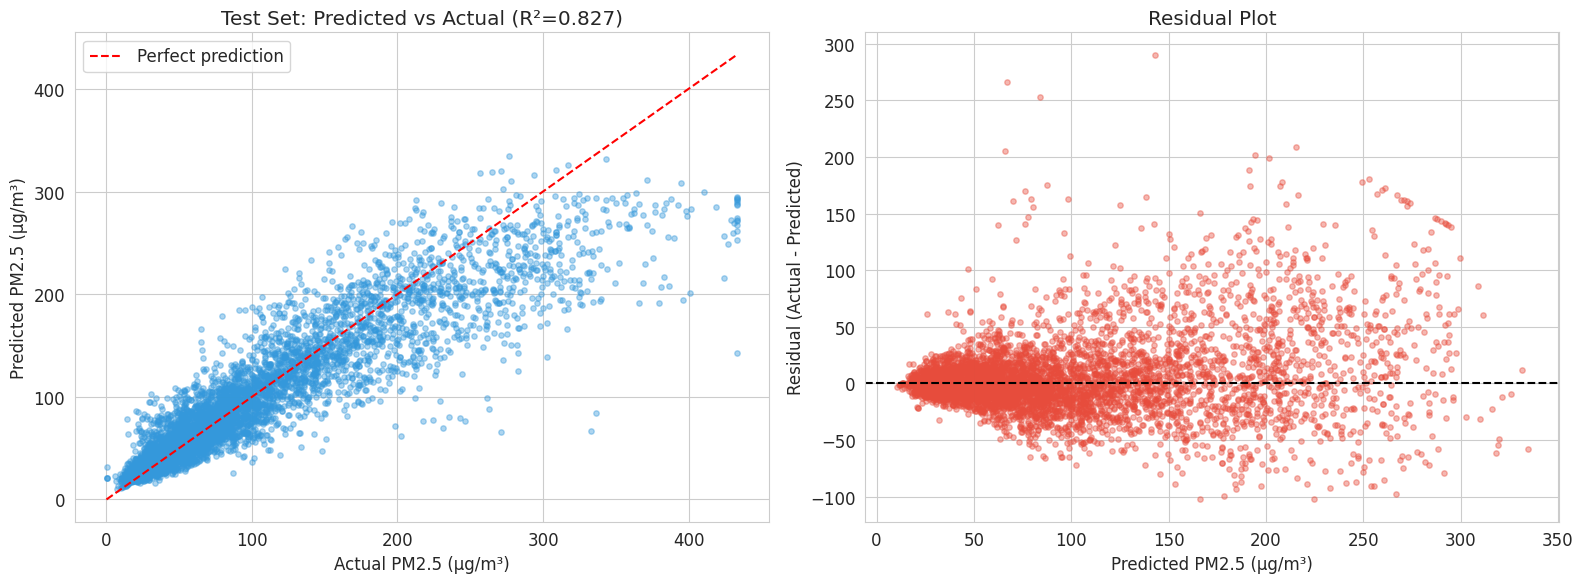

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter
test_preds = np.expm1(model.predict(X_test))
test_actual = np.expm1(y_test)

axes[0].scatter(test_actual, test_preds, alpha=0.4, color="#3498DB", s=15)
axes[0].plot([0, test_actual.max()], [0, test_actual.max()],
             color="red", linestyle="--", label="Perfect prediction")
axes[0].set_xlabel("Actual PM2.5 (µg/m³)")
axes[0].set_ylabel("Predicted PM2.5 (µg/m³)")
axes[0].set_title(f"Test Set: Predicted vs Actual (R²={test_metrics['R2']:.3f})")
axes[0].legend()

# Residuals
residuals = test_actual - test_preds
axes[1].scatter(test_preds, residuals, alpha=0.4, color="#E74C3C", s=15)
axes[1].axhline(0, color="black", linestyle="--")
axes[1].set_xlabel("Predicted PM2.5 (µg/m³)")
axes[1].set_ylabel("Residual (Actual - Predicted)")
axes[1].set_title("Residual Plot")

plt.tight_layout()
plt.savefig("Delhi_PM25_AI/maps/XGB_Predictions.png", dpi=150)
plt.show()

In [ ]:
import os
os.makedirs("Delhi_PM25_AI/models", exist_ok=True)

model.save_model("Delhi_PM25_AI/models/xgboost_baseline.json")

results = {
    "model": "XGBoost Baseline",
    "train": train_metrics,
    "val":   val_metrics,
    "test":  test_metrics,
    "best_iteration": int(model.best_iteration)
}

with open("Delhi_PM25_AI/models/xgboost_baseline_results.json", "w") as f:
    json.dump(results, f, indent=2)

print("Model and results saved")

Model and results saved


In [ ]:
import os

# Check current working directory
print("Current directory:", os.getcwd())

# Search for the file
for root, dirs, files in os.walk("/content"):
    for file in files:
        if "xgboost_baseline" in file:
            print(os.path.join(root, file))

Current directory: /content
/content/Delhi_PM25_AI/models/xgboost_baseline.json
/content/Delhi_PM25_AI/models/xgboost_baseline_results.json
/content/drive/MyDrive/Delhi_PM25_AI/models/xgboost_baseline_results.json
/content/drive/MyDrive/Delhi_PM25_AI/models/xgboost_baseline.json


In [ ]:
import os
os.makedirs("/content/drive/MyDrive/Delhi_PM25_AI/models", exist_ok=True)

model.save_model("/content/drive/MyDrive/Delhi_PM25_AI/models/xgboost_baseline.json")

In [ ]:
print(os.getcwd())
print(os.path.exists("Delhi_PM25_AI/data/final/Master_PM25_Dataset.csv"))

/content
False


In [ ]:
for root, dirs, files in os.walk("/content/drive/MyDrive"):
    for file in files:
        if file == "Master_PM25_Dataset.csv":
            print(os.path.join(root, file))

/content/drive/MyDrive/Master_PM25_Dataset.csv
/content/drive/MyDrive/Delhi_PM25_AI/data/final/Master_PM25_Dataset.csv
/content/drive/MyDrive/Delhi_PM25_AI/scripts/Delhi_PM25_AI/data/final/Master_PM25_Dataset.csv


In [ ]:
import os

PROJECT_ROOT = "/content/drive/MyDrive/Delhi_PM25_AI"

# Verify the folder and key files exist
checks = [
    "data/final/Master_PM25_Dataset.csv",
    "data/processed/ml_ready/train.csv",
    "data/processed/ml_ready/val.csv",
    "data/processed/ml_ready/test.csv",
    "data/processed/ml_ready/feature_cols.json",
]

for c in checks:
    full_path = os.path.join(PROJECT_ROOT, c)
    exists = os.path.exists(full_path)
    print(f"{'✅' if exists else '❌'} {c}")

✅ data/final/Master_PM25_Dataset.csv
❌ data/processed/ml_ready/train.csv
❌ data/processed/ml_ready/val.csv
❌ data/processed/ml_ready/test.csv
❌ data/processed/ml_ready/feature_cols.json


In [ ]:
ml_ready_dir = os.path.join(PROJECT_ROOT, "data/processed/ml_ready")
os.makedirs(ml_ready_dir, exist_ok=True)

train.to_csv(os.path.join(ml_ready_dir, "train.csv"), index=False)
val.to_csv(os.path.join(ml_ready_dir, "val.csv"), index=False)
test.to_csv(os.path.join(ml_ready_dir, "test.csv"), index=False)

with open(os.path.join(ml_ready_dir, "feature_cols.json"), "w") as f:
    json.dump(feature_cols, f)

print(f"\n✅ Saved to Drive: {ml_ready_dir}")


✅ Saved to Drive: /content/drive/MyDrive/Delhi_PM25_AI/data/processed/ml_ready


In [ ]:
for c in ["train.csv","val.csv","test.csv","feature_cols.json"]:
    p = os.path.join(ml_ready_dir, c)
    print(f"{'✅' if os.path.exists(p) else '❌'} {c}")

✅ train.csv
✅ val.csv
✅ test.csv
✅ feature_cols.json


# LightGBM

In [ ]:
!pip install optuna lightgbm -q

import lightgbm as lgb
import optuna
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import json
import os

PROJECT_ROOT = "/content/drive/MyDrive/Delhi_PM25_AI"
ml_ready_dir = os.path.join(PROJECT_ROOT, "data/processed/ml_ready")

train = pd.read_csv(os.path.join(ml_ready_dir, "train.csv"), parse_dates=["Date"])
val   = pd.read_csv(os.path.join(ml_ready_dir, "val.csv"),   parse_dates=["Date"])
test  = pd.read_csv(os.path.join(ml_ready_dir, "test.csv"),  parse_dates=["Date"])

with open(os.path.join(ml_ready_dir, "feature_cols.json")) as f:
    feature_cols = json.load(f)

target_col = "log_PM25_capped"

X_train, y_train = train[feature_cols], train[target_col]
X_val,   y_val   = val[feature_cols],   val[target_col]
X_test,  y_test  = test[feature_cols],  test[target_col]

print(f"Train: {len(X_train):,}  Val: {len(X_val):,}  Test: {len(X_test):,}")

Train: 28,770  Val: 5,744  Test: 5,814


In [ ]:
def objective(trial):
    params = {
        "objective"        : "regression",
        "metric"           : "rmse",
        "verbosity"        : -1,
        "boosting_type"    : "gbdt",
        "n_estimators"     : 1000,
        "learning_rate"    : trial.suggest_float("learning_rate", 0.005, 0.1, log=True),
        "num_leaves"       : trial.suggest_int("num_leaves", 20, 150),
        "max_depth"        : trial.suggest_int("max_depth", 3, 12),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        "subsample"        : trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree" : trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha"        : trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda"       : trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "random_state"     : 42,
    }

    model = lgb.LGBMRegressor(**params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(50, verbose=False)]
    )

    preds = model.predict(X_val, num_iteration=model.best_iteration_)
    rmse  = np.sqrt(mean_squared_error(y_val, preds))
    return rmse

# ── Run optimization ───────────────────────────────────────────────────────────
print("Starting Optuna hyperparameter search...")
print("This will take 10-20 minutes for 50 trials\n")

study = optuna.create_study(direction="minimize", study_name="lgb_pm25")
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\nBest RMSE (log scale): {study.best_value:.4f}")
print(f"Best params:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

[I 2026-06-30 17:03:05,964] A new study created in memory with name: lgb_pm25


Starting Optuna hyperparameter search...
This will take 10-20 minutes for 50 trials



  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-06-30 17:03:16,844] Trial 0 finished with value: 0.2871045940175914 and parameters: {'learning_rate': 0.01400400480458868, 'num_leaves': 40, 'max_depth': 12, 'min_child_samples': 51, 'subsample': 0.8002401718174289, 'colsample_bytree': 0.853708602370632, 'reg_alpha': 0.44036610729493997, 'reg_lambda': 0.0020560731212459337}. Best is trial 0 with value: 0.2871045940175914.
[I 2026-06-30 17:03:18,998] Trial 1 finished with value: 0.28916087502003224 and parameters: {'learning_rate': 0.04655883333770045, 'num_leaves': 31, 'max_depth': 11, 'min_child_samples': 100, 'subsample': 0.851937048189283, 'colsample_bytree': 0.9941018337777372, 'reg_alpha': 0.004502079477072894, 'reg_lambda': 0.0008410698979920141}. Best is trial 0 with value: 0.2871045940175914.
[I 2026-06-30 17:03:20,593] Trial 2 finished with value: 0.2925413379101145 and parameters: {'learning_rate': 0.024676233774351155, 'num_leaves': 140, 'max_depth': 3, 'min_child_samples': 47, 'subsample': 0.5797198129033957, 'colsa

In [ ]:
best_params = study.best_params.copy()
best_params.update({
    "objective"    : "regression",
    "metric"       : "rmse",
    "n_estimators" : 2000,
    "random_state" : 42,
    "verbosity"    : -1,
})

lgb_model = lgb.LGBMRegressor(**best_params)
lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    callbacks=[lgb.early_stopping(50, verbose=True)]
)

print(f"\nBest iteration: {lgb_model.best_iteration_}")

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[316]	training's rmse: 0.193911	valid_1's rmse: 0.284804

Best iteration: 316


In [ ]:
def evaluate(model, X, y, set_name):
    preds_log    = model.predict(X, num_iteration=model.best_iteration_)
    preds_actual = np.expm1(preds_log)
    y_actual     = np.expm1(y)

    mae  = mean_absolute_error(y_actual, preds_actual)
    rmse = np.sqrt(mean_squared_error(y_actual, preds_actual))
    r2   = r2_score(y_actual, preds_actual)
    mape = np.mean(np.abs((y_actual - preds_actual) / y_actual)) * 100

    print(f"{set_name:12s} MAE: {mae:6.2f}  RMSE: {rmse:6.2f}  R²: {r2:.4f}  MAPE: {mape:5.1f}%")
    return {"MAE": mae, "RMSE": rmse, "R2": r2, "MAPE": mape}

print("LightGBM (Optuna-tuned) Performance:\n")
train_metrics = evaluate(lgb_model, X_train, y_train, "Train")
val_metrics   = evaluate(lgb_model, X_val,   y_val,   "Validation")
test_metrics  = evaluate(lgb_model, X_test,  y_test,  "Test")

LightGBM (Optuna-tuned) Performance:

Train        MAE:  13.76  RMSE:  21.17  R²: 0.9330  MAPE:  17.1%
Validation   MAE:  20.85  RMSE:  32.18  R²: 0.8503  MAPE:  36.3%
Test         MAE:  20.63  RMSE:  32.81  R²: 0.8337  MAPE:  52.2%


In [ ]:
xgb_results_path = os.path.join(PROJECT_ROOT, "models/xgboost_baseline_results.json")

if os.path.exists(xgb_results_path):
    with open(xgb_results_path) as f:
        xgb_results = json.load(f)

    comparison = pd.DataFrame({
        "XGBoost (Phase 3)" : xgb_results["test"],
        "LightGBM (Phase 4)": test_metrics,
    }).T

    print("Model Comparison — Test Set:")
    print(comparison.round(3))

    improvement = (xgb_results["test"]["RMSE"] - test_metrics["RMSE"]) / xgb_results["test"]["RMSE"] * 100
    print(f"\nRMSE improvement over XGBoost: {improvement:+.1f}%")
else:
    print("⚠️ XGBoost results not found — save xgboost_baseline_results.json to Drive first")
    print(f"Looking at: {xgb_results_path}")

Model Comparison — Test Set:
                       MAE    RMSE     R2    MAPE
XGBoost (Phase 3)   20.426  32.704  0.835  53.227
LightGBM (Phase 4)  20.633  32.812  0.834  52.153

RMSE improvement over XGBoost: -0.3%


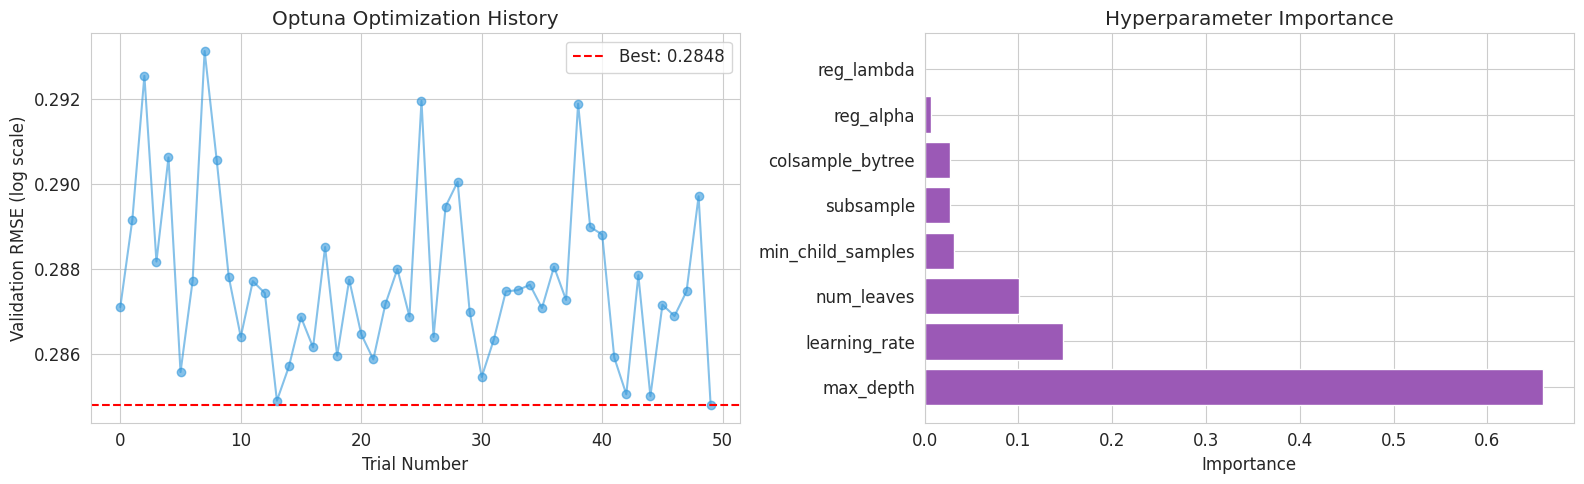

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

trials_df = study.trials_dataframe()
axes[0].plot(trials_df["number"], trials_df["value"], "o-", alpha=0.6, color="#3498DB")
axes[0].axhline(study.best_value, color="red", linestyle="--", label=f"Best: {study.best_value:.4f}")
axes[0].set_xlabel("Trial Number")
axes[0].set_ylabel("Validation RMSE (log scale)")
axes[0].set_title("Optuna Optimization History")
axes[0].legend()

importance = optuna.importance.get_param_importances(study)
axes[1].barh(list(importance.keys()), list(importance.values()), color="#9B59B6")
axes[1].set_title("Hyperparameter Importance")
axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, "maps/Optuna_Tuning_Results.png"), dpi=150)
plt.show()

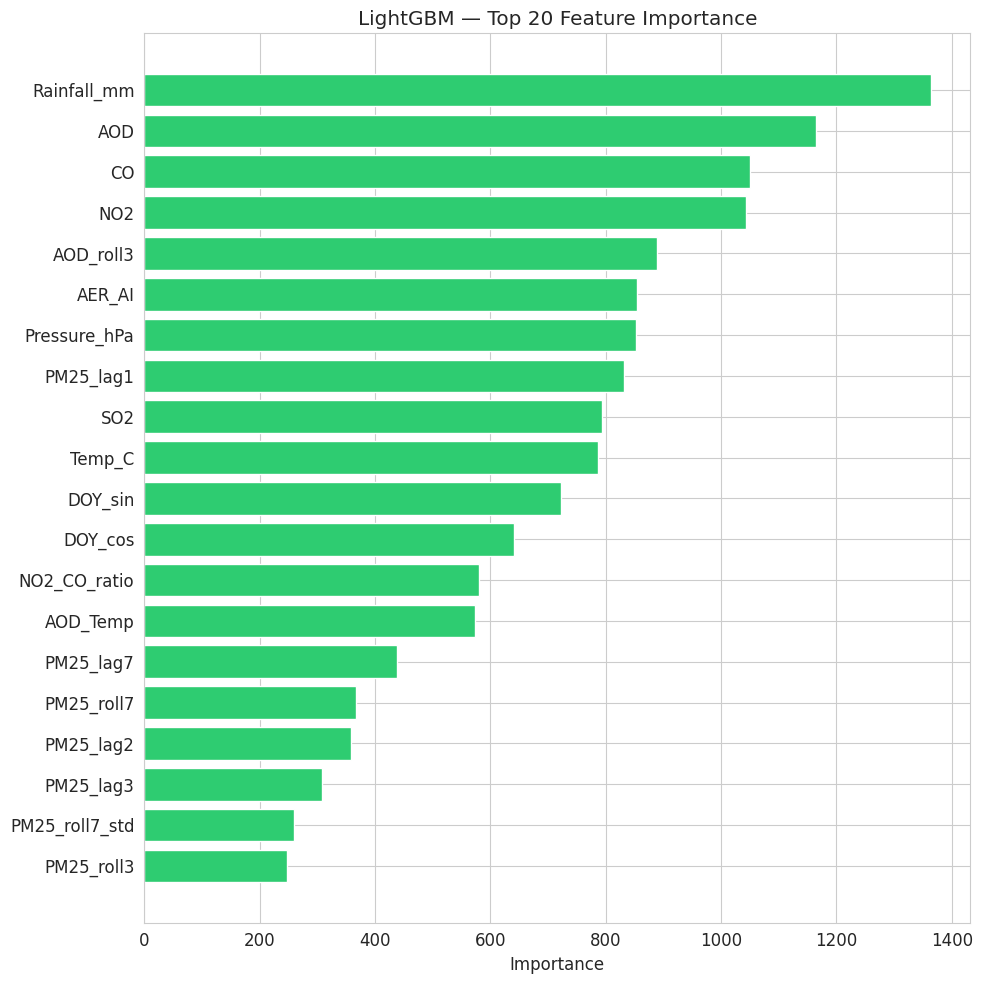

         feature  importance
7    Rainfall_mm        1364
0            AOD        1165
3             CO        1050
1            NO2        1043
30     AOD_roll3         889
4         AER_AI         854
8   Pressure_hPa         853
23     PM25_lag1         832
2            SO2         794
6         Temp_C         787
21       DOY_sin         722
22       DOY_cos         641
20  NO2_CO_ratio         581
19      AOD_Temp         573
26     PM25_lag7         438


In [ ]:
lgb_importance = pd.DataFrame({
    "feature"   : feature_cols,
    "importance": lgb_model.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(10, 10))
plt.barh(lgb_importance["feature"][:20][::-1], lgb_importance["importance"][:20][::-1],
         color="#2ECC71", edgecolor="white")
plt.title("LightGBM — Top 20 Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, "maps/LGB_Feature_Importance.png"), dpi=150)
plt.show()

print(lgb_importance.head(15).to_string())

In [ ]:
import joblib

models_dir = os.path.join(PROJECT_ROOT, "models")
os.makedirs(models_dir, exist_ok=True)

joblib.dump(lgb_model, os.path.join(models_dir, "lightgbm_optuna.pkl"))

results = {
    "model"        : "LightGBM + Optuna",
    "best_params"  : study.best_params,
    "train"        : train_metrics,
    "val"          : val_metrics,
    "test"         : test_metrics,
    "best_iteration": int(lgb_model.best_iteration_),
}

with open(os.path.join(models_dir, "lightgbm_optuna_results.json"), "w") as f:
    json.dump(results, f, indent=2)

print(f"✅ Saved to {models_dir}")

✅ Saved to /content/drive/MyDrive/Delhi_PM25_AI/models


# LSTM

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import json
import os

PROJECT_ROOT = "/content/drive/MyDrive/Delhi_PM25_AI"
ml_ready_dir = os.path.join(PROJECT_ROOT, "data/processed/ml_ready")

train = pd.read_csv(os.path.join(ml_ready_dir, "train.csv"), parse_dates=["Date"])
val   = pd.read_csv(os.path.join(ml_ready_dir, "val.csv"),   parse_dates=["Date"])
test  = pd.read_csv(os.path.join(ml_ready_dir, "test.csv"),  parse_dates=["Date"])

with open(os.path.join(ml_ready_dir, "feature_cols.json")) as f:
    feature_cols = json.load(f)

target_col = "log_PM25_capped"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(train[feature_cols])

train_scaled = train.copy()
val_scaled   = val.copy()
test_scaled  = test.copy()

train_scaled[feature_cols] = scaler.transform(train[feature_cols])
val_scaled[feature_cols]   = scaler.transform(val[feature_cols])
test_scaled[feature_cols]  = scaler.transform(test[feature_cols])

# Save scaler for later use
import joblib
os.makedirs(os.path.join(PROJECT_ROOT, "models"), exist_ok=True)
joblib.dump(scaler, os.path.join(PROJECT_ROOT, "models/lstm_scaler.pkl"))

['/content/drive/MyDrive/Delhi_PM25_AI/models/lstm_scaler.pkl']

In [ ]:
SEQ_LEN = 14  # 14-day lookback window

def build_sequences(df, feature_cols, target_col, seq_len=SEQ_LEN):
    X_seqs, y_vals = [], []
    df = df.sort_values(["Grid_ID","Date"])

    for grid_id, group in df.groupby("Grid_ID"):
        group = group.reset_index(drop=True)
        feats = group[feature_cols].values
        target = group[target_col].values

        for i in range(seq_len, len(group)):
            X_seqs.append(feats[i-seq_len:i])
            y_vals.append(target[i])

    return np.array(X_seqs), np.array(y_vals)

X_train_seq, y_train_seq = build_sequences(train_scaled, feature_cols, target_col)
X_val_seq,   y_val_seq   = build_sequences(val_scaled,   feature_cols, target_col)
X_test_seq,  y_test_seq  = build_sequences(test_scaled,  feature_cols, target_col)

print(f"Train sequences : {X_train_seq.shape}")
print(f"Val sequences   : {X_val_seq.shape}")
print(f"Test sequences  : {X_test_seq.shape}")

Train sequences : (28546, 14, 35)
Val sequences   : (5520, 14, 35)
Test sequences  : (5590, 14, 35)


In [ ]:
class PM25Dataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = PM25Dataset(X_train_seq, y_train_seq)
val_ds   = PM25Dataset(X_val_seq,   y_val_seq)
test_ds  = PM25Dataset(X_test_seq,  y_test_seq)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False)

In [ ]:
class PM25_LSTM(nn.Module):
    def __init__(self, n_features, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size  = n_features,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            batch_first = True,
            dropout     = dropout if num_layers > 1 else 0
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        lstm_out, (h_n, c_n) = self.lstm(x)
        last_hidden = lstm_out[:, -1, :]
        return self.fc(last_hidden).squeeze(-1)

model = PM25_LSTM(n_features=len(feature_cols)).to(device)
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

PM25_LSTM(
  (lstm): LSTM(35, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)

Total parameters: 61,249


In [ ]:
import torch.optim as optim

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=5)

best_val_loss = float("inf")
patience_counter = 0
patience_limit = 15
history = {"train_loss": [], "val_loss": []}

for epoch in range(100):
    model.train()
    train_losses = []
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_losses.append(loss.item())

    model.eval()
    val_losses = []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            preds = model(X_batch)
            val_losses.append(criterion(preds, y_batch).item())

    train_loss = np.mean(train_losses)
    val_loss   = np.mean(val_losses)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    scheduler.step(val_loss)

    if epoch % 5 == 0:
        print(f"Epoch {epoch:3d}  Train Loss: {train_loss:.4f}  Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(),
                   os.path.join(PROJECT_ROOT, "models/lstm_best.pt"))
    else:
        patience_counter += 1
        if patience_counter >= patience_limit:
            print(f"\nEarly stopping at epoch {epoch}")
            break

print(f"\nBest validation loss: {best_val_loss:.4f}")

Epoch   0  Train Loss: nan  Val Loss: nan
Epoch   5  Train Loss: nan  Val Loss: nan
Epoch  10  Train Loss: nan  Val Loss: nan

Early stopping at epoch 14

Best validation loss: inf


In [ ]:
# Download XGBoost baseline
files.download(os.path.join(models_dir, "xgboost_baseline.json"))
files.download(os.path.join(models_dir, "xgboost_baseline_results.json"))

# Download LightGBM
files.download(os.path.join(models_dir, "lightgbm_optuna.pkl"))
files.download(os.path.join(models_dir, "lightgbm_optuna_results.json"))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import shutil

zip_path = "/content/Delhi_PM25_AI_models"
shutil.make_archive(zip_path, "zip", models_dir)

files.download(zip_path + ".zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>